# Домашнее задание 6

Перед выполнением заданий необходимо сохранить копию этого блокнота себе на диск. Или скачать `.ipynb`/`.py` файл для локальной разработки.

За работу можно получить максимум 8 баллов.

Вы можете сдавать эту работу как на R, так и на Python.

# Задание 1 (3 балла)

В [папке](https://drive.google.com/drive/folders/1kwbJk5jottoSMep2rDEefeE_26-LQp1D?usp=sharing) вы можете найти данные для работы.

Необходимо объединить таблицы таким образом, чтобы вывести информацию с ответами на следующие вопросы:
* по какой услуге клиенты чаще всего оставляли запросы?
* сколько запросов поступило от женщин и мужчин?
* вывести информацию о том, по какому региону по какой услуге было больше всего запросов? вывести информацию в порядке убывания общего числа запросов, указать название самой популярной услуге (если их несколько) и в алфавитном порядке по региону

In [ ]:
import pandas as pd

sdata = {
    'si': [1, 2, 3, 4, 5, 6],
    'sn': ['консультация m', 'консультация n', 'консультации n',
                     'чат-бот', 'обслуживание f', 'обслуживание r']
}
s_df = pd.DataFrame(sdata)

manager_text = """2020b1/01
2020b1/02/01
R i n e r p o s A l
R C u a o p o s
H M s a n o s K t
h Ф е д о р о s
I Д а н и л о s
I П у т и Б А К 6
I С е н к е в ч
I М а р к и н И"""

lines = manager_text.strip().split('\n')
mn = [line.strip() for line in lines if line.strip() and not line.startswith('2020')]
md = {
    'mi': list(range(1, len(mn) + 1)),
    'mn': mn
}
m_df = pd.DataFrame(md)

c_data = {
    'ci': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'cn': ['Пушкин А.С.', 'Тургенев И.С.', 'Горький А.М.', 'Толстой Л.Н.',
                    'Барто А.И.', 'Гайдар А.П.', 'Усистя А.', 'Верн Ж.',
                    'Брохт Б.', 'Саид Ж.'],
    'g': ['м', 'м', 'м', 'м', 'ж', 'м', 'ж', 'м', 'м', 'ж']
}
c_df = pd.DataFrame(c_data)

vd = {
    'vi': [4, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13],
    'vd': ['2025-05-20', '2025-04-25', '2025-05-25', '2025-09-09',
                   '2025-04-01', '2025-02-22', '2025-10-11', '2025-07-14',
                   '2025-03-29', '2025-02-09', '2025-06-17', '2025-09-30', '2025-03-12'],
    'bi': [2, 3, 2, 3, 1, 1, 2, 7, 8, 6, 7, 9, 5],
    'ci': [1, 2, 4, 1, 3, 2, 1, 9, 5, 9, 8, 7, 10],
    'mi': [2, 3, 2, 3, 1, 1, 2, 5, 7, 8, 6, 5, 8],
    'si': [1, 4, 3, 1, 1, 2, 3, 6, 3, 5, 4, 5, 6]
}
v_df = pd.DataFrame(vd)

bd = {
    'bi': [1, 2, 3, 4, 5, 6, 7, 8, 9],  # Исправлено: должно быть 'bi', а не 'bI'
    'bn': ['отделение ц', 'отделение з', 'отделение ю',
                    'отделение в', 'отделение с', 'отделение оз',
                    'отделение юв', 'отделение св', 'отделение юз']
}
b_df = pd.DataFrame(bd)

merged_df = v_df.merge(c_df, on='ci', how='left') \
                   .merge(s_df, on='si', how='left') \
                   .merge(b_df, on='bi', how='left') \
                   .merge(m_df, on='mi', how='left')

print("таблица")
print(merged_df[['vi', 'cn', 'g', 'sn', 'bn']].head())
print("\n" + "="*50 + "\n")

print("1.популярная услуга:")
sc = merged_df['sn'].value_counts()
mps = sc.idxmax()
mpc = sc.max()
print(f"услуга: {mps}")
print(f"колво запросов: {mpc}")
print("\n" + "-"*30 + "\n")

print("2. мж:")

merged_df['gn'] = merged_df['g'].map({'м': 'мужчины', 'ж': 'женщины'})
gс = merged_df['gn'].value_counts()
for g, c in gс.items():
    print(f"{g}: {c} запросов")
print("\n" + "-"*30 + "\n")

print("3. стата по регионам:")
rss = merged_df.groupby(['bn', 'sn']).size().reset_index(name='c')
rss = rss.sort_values(['c', 'bn'], ascending=[False, True])

print("регоны и услуг по убыванию:")
print("-" * 50)
for idx, row in rss.iterrows():
    print(f"регион: {row['bn']:<20} |услуга: {row['sn']:<20} | запросов: {row['c']}")

print("\n" + "-" * 50)
print("комбинации:")
top_combinations = rss.head(3)
for idx, row in top_combinations.iterrows():
    print(f"• {row['bn']} - {row['sn']}: {row['c']} запросов")

print("\n" + "="*50)
print("доп инфа:")
print(f"всего {len(merged_df)}")
print(f"клиенты: {merged_df['ci'].nunique()}")
print(f"услуги: {merged_df['sn'].nunique()}")
print(f"регионы: {merged_df['bn'].nunique()}")

таблица
   vi             cn  g              sn           bn
0   4    Пушкин А.С.  м  консультация m  отделение з
1   1  Тургенев И.С.  м         чат-бот  отделение ю
2   2   Толстой Л.Н.  м  консультации n  отделение з
3   3    Пушкин А.С.  м  консультация m  отделение ю
4   5   Горький А.М.  м  консультация m  отделение ц


1.популярная услуга:
услуга: консультация m
колво запросов: 3

------------------------------

2. мж:
мужчины: 10 запросов
женщины: 3 запросов

------------------------------

3. стата по регионам:
регоны и услуг по убыванию:
--------------------------------------------------
регион: отделение з          |услуга: консультации n       | запросов: 2
регион: отделение з          |услуга: консультация m       | запросов: 1
регион: отделение оз         |услуга: обслуживание f       | запросов: 1
регион: отделение с          |услуга: обслуживание r       | запросов: 1
регион: отделение св         |услуга: консультации n       | запросов: 1
регион: отделение ц          |

# Задание 2 (5 баллов)

В [папке](https://drive.google.com/drive/folders/16JRLbMGbNc36eHe8wG4isHUgfQzu7n0z?usp=sharing) вы можете найти данные для работы.


В датасете представлена информация о продаже компьютерных игр. Можно представить, что ваша задача - собрать самые интересные факты про рынок компьютерных игр на основе этого датасета.

Визуализировать различными способами минимум три признака, а также минимум три взаимодействия между признаками.


In [ ]:

import pandas as pd

df = pd.read_csv("/content/video_games_sales.csv")

df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


Saving video_games_sales.csv to video_games_sales (2).csv


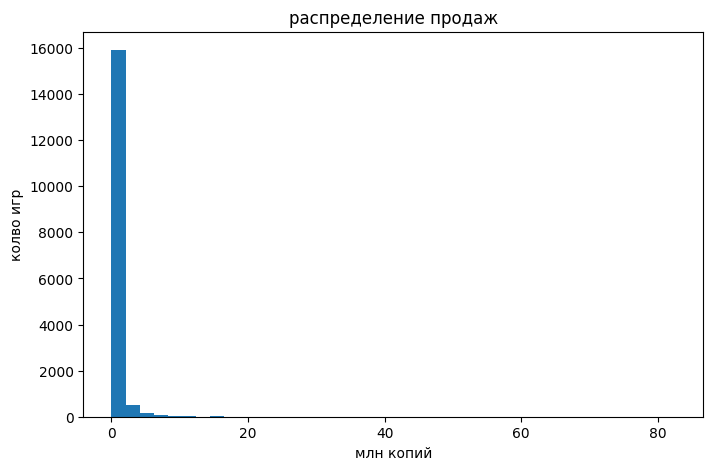

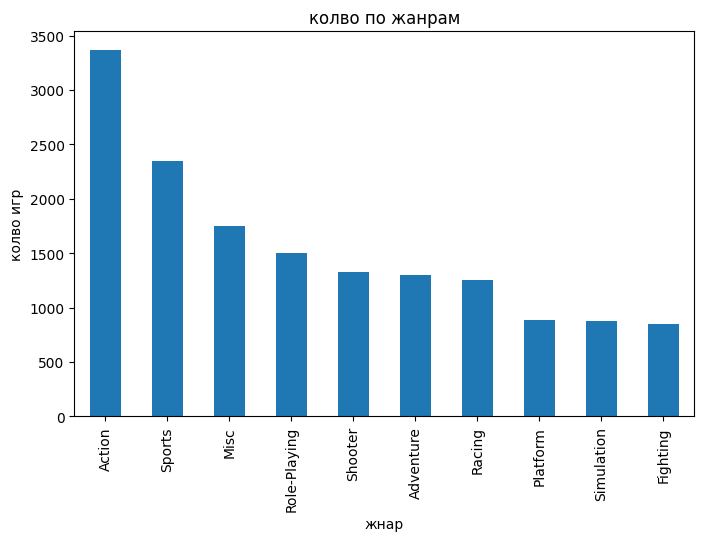

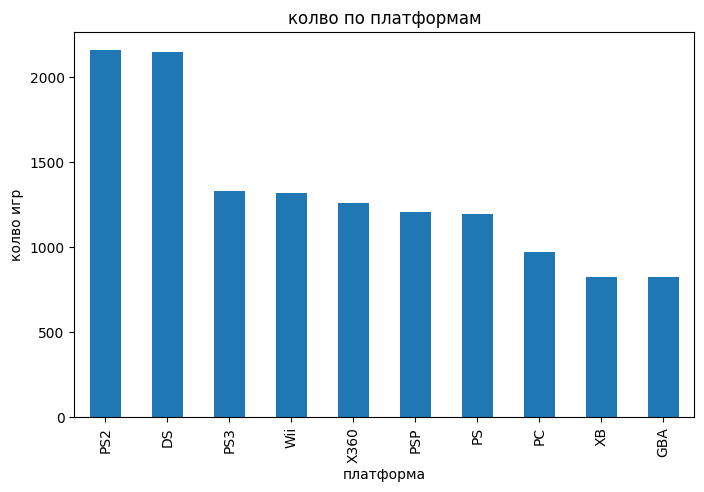

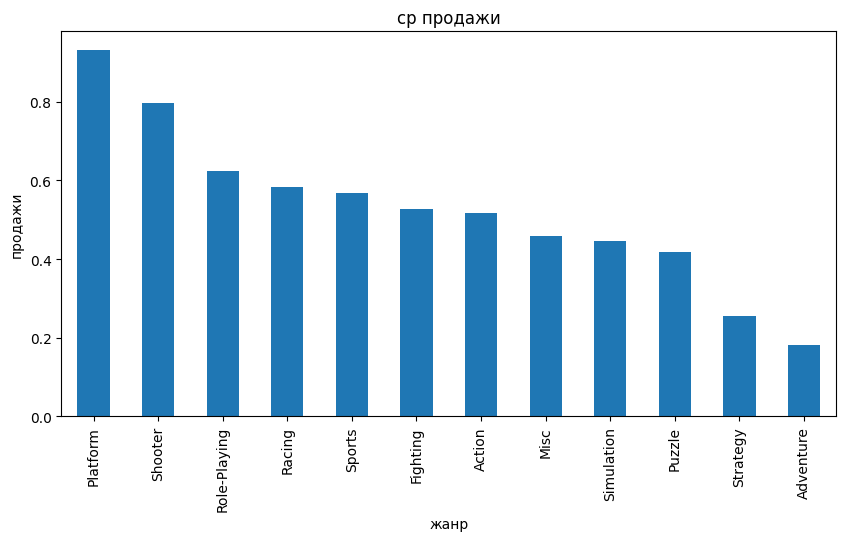

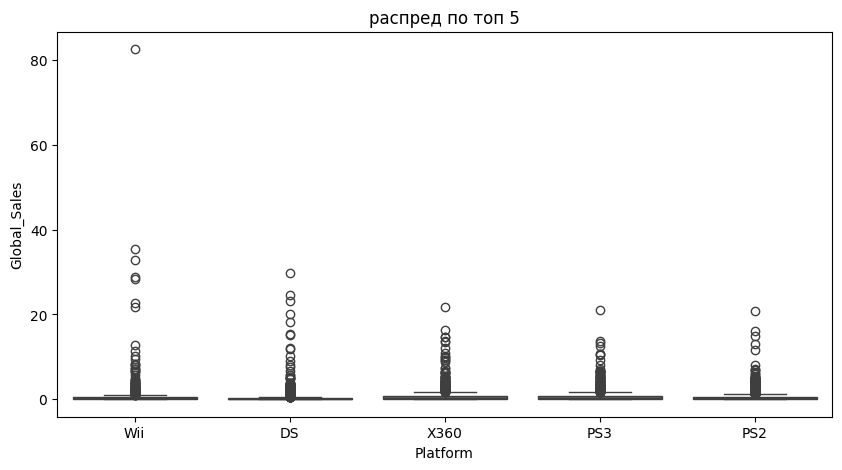

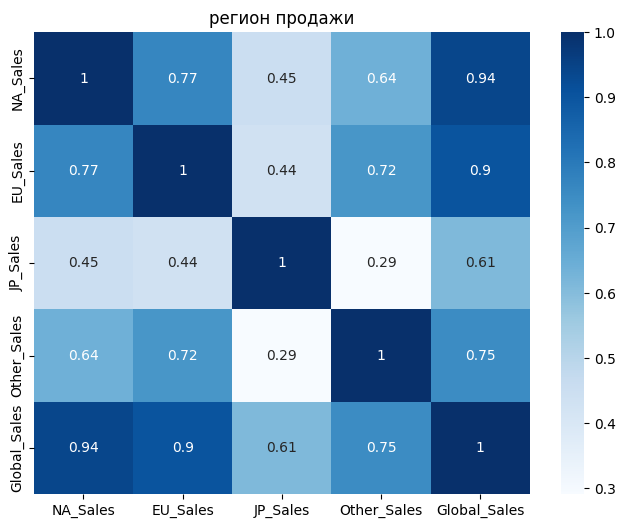

In [ ]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(list(uploaded.keys())[0])
df.head()
plt.figure(figsize=(8, 5))
plt.hist(df["Global_Sales"], bins=40)
plt.title("распределение продаж")
plt.xlabel("млн копий")
plt.ylabel("колво игр")
plt.show()

plt.figure(figsize=(8, 5))
df["Genre"].value_counts().head(10).plot(kind="bar")
plt.title("колво по жанрам")
plt.xlabel("жнар")
plt.ylabel("колво игр")
plt.show()
plt.figure(figsize=(8, 5))
df["Platform"].value_counts().head(10).plot(kind="bar")
plt.title("колво по платформам")
plt.xlabel("платформа")
plt.ylabel("колво игр")
plt.show()
plt.figure(figsize=(10, 5))
df.groupby("Genre")["Global_Sales"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("ср продажи")
plt.xlabel("жанр")
plt.ylabel("продажи")
plt.show()
top5_platforms = df["Platform"].value_counts().head(5).index

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df[df["Platform"].isin(top5_platforms)],
    x="Platform",
    y="Global_Sales"
)
plt.title("распред по топ 5")
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(
    df[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales", "Global_Sales"]].corr(),
    annot=True,
    cmap="Blues"
)
plt.title("регион продажи")
plt.show()